<a href="https://colab.research.google.com/github/ManhattanCB01-nyc/CrashVehiclesDataPipeline/blob/main/crasheswithintersectionnumber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# crasheswithintersectionnumber

Creates a crash-level BigQuery table with `intersection_id` added to every crash row using the same 20-meter DBSCAN intersection approach from the supplied notebook.

BigQuery output:
`stable-liberty-426016-d2.new_dataset.crasheswithintersectionnumber`

The output keeps all original crash rows and adds:
- `intersection_id`
- `intersection_lat`
- `intersection_lon`
- `intersection_collision_count`
- `intersection_on_street_name`
- `intersection_off_street_name`


In [ ]:
!pip install -q openpyxl scikit-learn google-cloud-bigquery pandas-gbq

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ===== SETTINGS =====
DRIVE_FILE_PATH = "/content/drive/MyDrive/manhattan_cb1_collisions/data/manhattan_cb1_collisions_2018plus_copy.xlsx"

PROJECT_ID = "stable-liberty-426016-d2"
BQ_DATASET = "new_dataset"
BQ_TABLE = "crasheswithintersectionnumber"

CLUSTER_RADIUS_METERS = 20

OUTPUT_CSV_PATH = (
    "/content/drive/MyDrive/manhattan_cb1_collisions/"
    "crasheswithintersectionnumber.csv"
)

print(f"Output: {PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}")

Output: stable-liberty-426016-d2.new_dataset.crasheswithintersectionnumber


In [ ]:
# ===== LOAD CRASHES =====
import pandas as pd
import numpy as np

raw = pd.read_excel(DRIVE_FILE_PATH, sheet_name="Crashes", header=None)

expected = {"crash_date", "borough", "latitude", "longitude", "collision_id"}
header_row_idx = None

for i, row in raw.iterrows():
    values = {str(v).strip().lower() for v in row if pd.notna(v)}
    if expected.issubset(values):
        header_row_idx = i
        break

if header_row_idx is None:
    df = pd.read_excel(DRIVE_FILE_PATH, sheet_name="Crashes")
else:
    header = [
        str(v).strip().lower() if pd.notna(v) else f"col_{j}"
        for j, v in raw.loc[header_row_idx].items()
    ]
    df = raw.drop(index=header_row_idx).reset_index(drop=True)
    df.columns = header

print(f"Loaded {len(df):,} crash rows.")

Loaded 4,296 crash rows.


In [ ]:
# ===== CLEAN COORDINATES =====
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["collision_id"] = pd.to_numeric(df["collision_id"], errors="coerce")

geo = df.dropna(
    subset=["latitude", "longitude", "collision_id"]
).copy()

geo = geo[
    (geo["latitude"] != 0) &
    (geo["longitude"] != 0)
].copy()

geo["collision_id"] = geo["collision_id"].astype("int64")

print(f"Rows with usable coordinates: {len(geo):,}")
print(f"Unique collisions: {geo['collision_id'].nunique():,}")

Rows with usable coordinates: 4,296
Unique collisions: 4,296


In [ ]:
# ===== 20-METER DBSCAN =====
from sklearn.cluster import DBSCAN

coords = geo[["latitude", "longitude"]].to_numpy()

EARTH_RADIUS_KM = 6371.0088
epsilon = (CLUSTER_RADIUS_METERS / 1000) / EARTH_RADIUS_KM

db = DBSCAN(
    eps=epsilon,
    min_samples=1,
    algorithm="ball_tree",
    metric="haversine"
).fit(np.radians(coords))

geo["cluster_id"] = db.labels_.astype("int64")

print(
    f"Found {geo['cluster_id'].nunique():,} "
    f"intersections using a {CLUSTER_RADIUS_METERS} m radius."
)

Found 720 intersections using a 20 m radius.


In [ ]:
# ===== BUILD INTERSECTION SUMMARY =====
def most_common(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    if s.empty:
        return None
    mode = s.mode()
    return mode.iloc[0] if not mode.empty else None

agg = {
    "intersection_collision_count": ("collision_id", "nunique"),
    "intersection_lat": ("latitude", "mean"),
    "intersection_lon": ("longitude", "mean"),
}

if "on_street_name" in geo.columns:
    agg["intersection_on_street_name"] = ("on_street_name", most_common)

if "off_street_name" in geo.columns:
    agg["intersection_off_street_name"] = ("off_street_name", most_common)

intersection_summary = (
    geo.groupby("cluster_id")
       .agg(**agg)
       .reset_index()
)

# Stable readable ID based on the representative intersection coordinate.
intersection_summary["intersection_id"] = (
    "INT_"
    + intersection_summary["intersection_lat"].round(6).map(lambda x: f"{x:.6f}")
    + "_"
    + intersection_summary["intersection_lon"].round(6).map(lambda x: f"{x:.6f}")
)

if intersection_summary["intersection_id"].duplicated().any():
    raise ValueError("Duplicate intersection_id values detected.")

display(
    intersection_summary.sort_values(
        "intersection_collision_count",
        ascending=False
    ).head(20)
)

,cluster_id,intersection_collision_count,intersection_lat,intersection_lon,intersection_on_street_name,intersection_off_street_name,intersection_id
51,51,86,40.706688,-74.015999,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999
23,23,73,40.710209,-74.001121,PEARL STREET,ROBERT F WAGNER PLACE,INT_40.710209_-74.001121
70,70,69,40.719395,-74.001890,CANAL STREET,BROADWAY,INT_40.719395_-74.001890
7,7,67,40.718429,-74.000533,CANAL STREET,LAFAYETTE STREET,INT_40.718429_-74.000533
89,89,66,40.722557,-74.006318,CANAL STREET,VARICK STREET,INT_40.722557_-74.006318
4,4,61,40.721351,-74.004649,CANAL STREET,WEST BROADWAY,INT_40.721351_-74.004649
25,25,58,40.718028,-73.999981,CANAL STREET,CENTRE STREET,INT_40.718028_-73.999981
208,208,55,40.720389,-74.003370,CANAL STREET,GREENE STREET,INT_40.720389_-74.003370
30,30,55,40.715236,-74.013378,WEST STREET,MURRAY STREET,INT_40.715236_-74.013378
104,104,53,40.709519,-74.001667,PEARL STREET,DOVER STREET,INT_40.709519_-74.001667


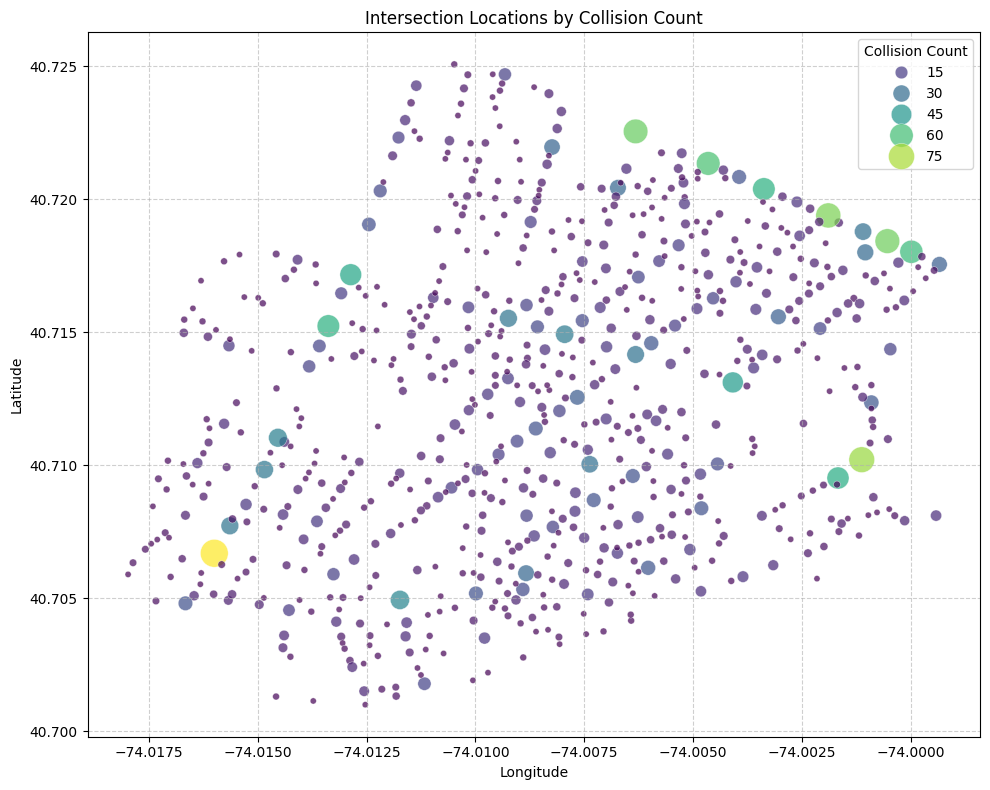

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='intersection_lon',
    y='intersection_lat',
    data=intersection_summary,
    hue='intersection_collision_count', # Color by collision count
    size='intersection_collision_count', # Size by collision count
    sizes=(20, 400), # Range of marker sizes
    alpha=0.7,
    palette='viridis'
)
plt.title('Intersection Locations by Collision Count')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Collision Count')
plt.tight_layout()
plt.show()

In [ ]:
import folium

# Calculate the center of the map based on the mean latitude and longitude
center_lat = intersection_summary['intersection_lat'].mean()
center_lon = intersection_summary['intersection_lon'].mean()

# Create a Folium map centered at the average location
m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

# Add markers for each intersection
for index, row in intersection_summary.iterrows():
    folium.CircleMarker(
        location=[row['intersection_lat'], row['intersection_lon']],
        radius=min(row['intersection_collision_count'] / 5, 20), # Scale radius by collision count, with a max
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        popup=f"Collision Count: {row['intersection_collision_count']}"
    ).add_to(m)

# Display the map
m

In [ ]:
# ===== ADD INTERSECTION DATA TO EACH CRASH =====
lookup = intersection_summary[
    [
        "cluster_id",
        "intersection_id",
        "intersection_lat",
        "intersection_lon",
        "intersection_collision_count",
        "intersection_on_street_name",
        "intersection_off_street_name",
    ]
].copy()

geo = geo.merge(
    lookup,
    on="cluster_id",
    how="left",
    validate="many_to_one"
)

# One collision must not map to multiple intersections.
mapping_check = geo.groupby("collision_id")["intersection_id"].nunique()

if (mapping_check > 1).any():
    raise ValueError("At least one collision maps to multiple intersections.")

# Keep every original crash row. Rows without usable coordinates simply
# have null intersection fields.
crash_lookup = (
    geo[
        [
            "collision_id",
            "intersection_id",
            "intersection_lat",
            "intersection_lon",
            "intersection_collision_count",
            "intersection_on_street_name",
            "intersection_off_street_name",
        ]
    ]
    .drop_duplicates("collision_id")
)

crasheswithintersectionnumber = df.merge(
    crash_lookup,
    on="collision_id",
    how="left",
    validate="one_to_one"
)

print(f"Original rows: {len(df):,}")
print(f"Output rows:   {len(crasheswithintersectionnumber):,}")
print(
    "Rows with intersection_id:",
    crasheswithintersectionnumber["intersection_id"].notna().sum()
)
print(
    "Rows without intersection_id:",
    crasheswithintersectionnumber["intersection_id"].isna().sum()
)

Original rows: 4,296
Output rows:   4,296
Rows with intersection_id: 4296
Rows without intersection_id: 0


In [ ]:
# ===== VALIDATE =====
assert len(crasheswithintersectionnumber) == len(df)
assert (
    crasheswithintersectionnumber["collision_id"].nunique()
    == df["collision_id"].nunique()
)

print("Validation passed.")
print(f"Intersections: {intersection_summary['intersection_id'].nunique():,}")

Validation passed.
Intersections: 720


In [ ]:
# ===== SAVE CSV COPY =====
crasheswithintersectionnumber.to_csv(
    OUTPUT_CSV_PATH,
    index=False
)
print(f"Saved: {OUTPUT_CSV_PATH}")

Saved: /content/drive/MyDrive/manhattan_cb1_collisions/crasheswithintersectionnumber.csv


In [ ]:
# ===== AUTHENTICATE + UPLOAD TO BIGQUERY =====
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

client = bigquery.Client(project=PROJECT_ID)

table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}"

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE
)

job = client.load_table_from_dataframe(
    crasheswithintersectionnumber,
    table_id,
    job_config=job_config
)

job.result()

print(f"SUCCESS: {len(crasheswithintersectionnumber):,} rows loaded.")
print(table_id)

SUCCESS: 4,296 rows loaded.
stable-liberty-426016-d2.new_dataset.crasheswithintersectionnumber


In [ ]:
# ===== VERIFY BIGQUERY TABLE =====
table = client.get_table(table_id)

print(f"Table: {table.full_table_id}")
print(f"Rows:  {table.num_rows:,}")
print("\nSchema:")

for field in table.schema:
    print(f"{field.name}: {field.field_type}")

Table: stable-liberty-426016-d2:new_dataset.crasheswithintersectionnumber
Rows:  4,296

Schema:
crash_date: DATETIME
crash_time: STRING
borough: STRING
zip_code: STRING
latitude: FLOAT
longitude: FLOAT
location: STRING
on_street_name: STRING
off_street_name: STRING
number_of_persons_injured: STRING
number_of_persons_killed: STRING
number_of_pedestrians_injured: STRING
number_of_pedestrians_killed: STRING
number_of_cyclist_injured: STRING
number_of_cyclist_killed: STRING
number_of_motorist_injured: STRING
number_of_motorist_killed: STRING
contributing_factor_vehicle_1: STRING
contributing_factor_vehicle_2: STRING
collision_id: INTEGER
vehicle_type_code1: STRING
vehicle_type_code2: STRING
cross_street_name: STRING
contributing_factor_vehicle_3: STRING
vehicle_type_code_3: STRING
contributing_factor_vehicle_4: STRING
vehicle_type_code_4: STRING
contributing_factor_vehicle_5: STRING
vehicle_type_code_5: STRING
intersection_id: STRING
intersection_lat: FLOAT
intersection_lon: FLOAT
intersec

In [ ]:
# ===== PREVIEW =====
query = f'''
SELECT
  collision_id,
  crash_date,
  crash_time,
  on_street_name,
  off_street_name,
  intersection_id,
  intersection_lat,
  intersection_lon,
  intersection_collision_count,
  intersection_on_street_name,
  intersection_off_street_name
FROM `{table_id}`
WHERE intersection_id IS NOT NULL
ORDER BY intersection_collision_count DESC, crash_date
LIMIT 20
'''

display(client.query(query).to_dataframe())

,collision_id,crash_date,crash_time,on_street_name,off_street_name,intersection_id,intersection_lat,intersection_lon,intersection_collision_count,intersection_on_street_name,intersection_off_street_name
0,4279554,2020-01-26,17:53,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
1,4289133,2020-02-14,11:18,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
2,4305865,2020-03-05,14:35,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
3,4305876,2020-03-08,0:16,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
4,4311389,2020-05-01,21:00,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
5,4351466,2020-08-22,20:47,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
6,4344394,2020-09-02,8:30,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
7,4347794,2020-09-11,17:55,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
8,4350443,2020-09-18,8:49,WEST STREET,MORRIS STREET,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
9,4368745,2020-11-18,16:05,None,None,INT_40.706688_-74.015999,40.706688,-74.015999,86,WEST STREET,MORRIS STREET
